In [1]:
import pandas as pd
df = pd.read_csv("NovaMarket_datos_crudos.csv")


In [2]:
df.isnull().sum()

id_pedido                      0
id_cliente                     0
fecha_compra                   0
canal                          0
ciudad                        31
codigo_postal                  0
categoria_producto             0
producto                       0
precio                        21
unidades                       0
edad_cliente                   0
correo                       104
nivel_satisfaccion            46
fecha_actualizacion_stock      0
dtype: int64

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

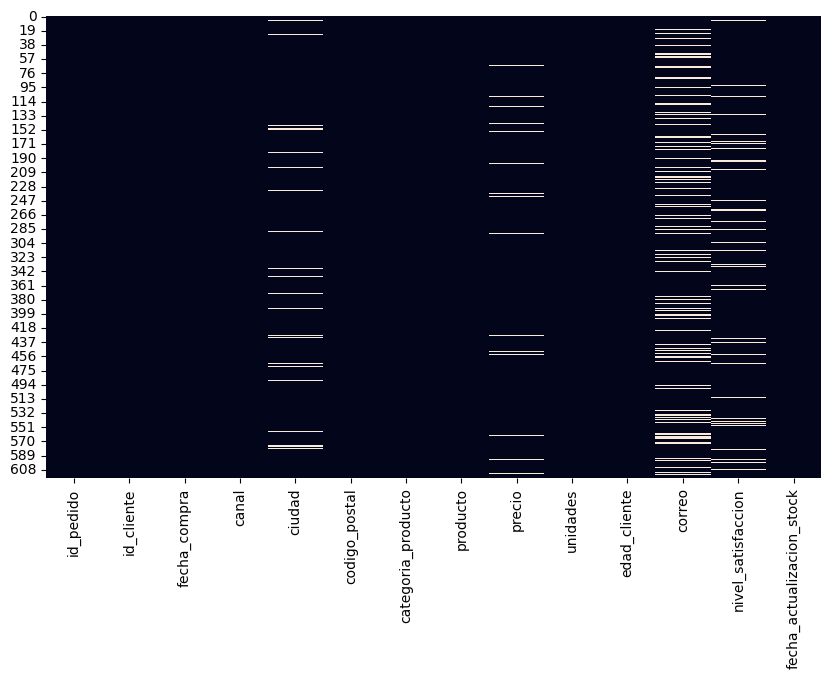

In [4]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False)
plt.show()

In [5]:
df[df["precio"].isnull()]["categoria_producto"].value_counts(normalize=True).sort_index()

categoria_producto
Belleza        0.095238
Deportes       0.095238
HOGAR          0.047619
Hogar          0.095238
Jugueteria     0.095238
Juguetería     0.047619
MODA           0.047619
Moda           0.047619
belleza        0.047619
deportes       0.142857
electronica    0.095238
hogar          0.142857
Name: proportion, dtype: float64

In [6]:
df["categoria_producto"].value_counts(normalize=True).sort_index()

categoria_producto
Belleza        0.106452
Deportes       0.095161
ELECTRONICA    0.027419
Electronica    0.053226
Electrónica    0.033871
HOGAR          0.054839
Hogar          0.053226
Jugueteria     0.045161
Juguetería     0.059677
MODA           0.056452
Moda           0.062903
belleza        0.087097
deportes       0.096774
electronica    0.029032
hogar          0.051613
juguetes       0.048387
moda           0.038710
Name: proportion, dtype: float64

## Diagnóstico de precio

**Conclusión: MAR (Missing At Random)**

**Justificación:**
Al comparar la distribución de categoria_producto entre los registros con precio faltante y la distribución general de categoria_producto en todo el dataset, se observan diferencias significativas en las proporciones de varias categorías.

Por ejemplo:
*   Las categorías 'Hogar', 'Jugueteria', 'deportes' y 'electronica' muestran una proporción notablemente más alta entre los valores faltantes de precio en comparación con su proporción en el conjunto de datos completo.

Estas diferencias indican que la probabilidad de que un valor de precio falte no es aleatoria, sino que está relacionada con la categoria_producto del registro (una variable observada). Esto se alinea con la definición de Missing At Random (MAR), donde la ausencia de datos puede predecirse a partir de otras variables disponibles en el dataset.

In [7]:
df.groupby("canal")["nivel_satisfaccion"].apply(lambda s: s.isnull().mean() * 100).round(1)

canal
App       9.2
Tienda    6.2
Web       6.7
Name: nivel_satisfaccion, dtype: float64

## Diagnóstico de nivel_satisfaccion
**Conclusión: MAR (Missing At Random)**

**Justificación:**
Al comparar la tasa de valores faltantes de nivel_satisfaccion entre los diferentes canal de compra, se observa que las proporciones son relativamente similares:
*   App: 9.2%
*   Tienda: 6.2%
*   Web: 6.7%

Aunque hay una ligera variación, ninguna de las tasas es "mucho más alta" (por ejemplo, más del doble) que otra. Esto sugiere que la probabilidad de que falte un valor en nivel_satisfaccion no está relacionada con el canal de compra ni con ninguna otra variable observada en el dataset. Por lo tanto, los datos se consideran Missing At Random (MAR).

In [8]:
df.groupby("canal")["ciudad"].apply(lambda s: s.isnull().mean() * 100).round(1)

canal
App       4.1
Tienda    5.4
Web       5.6
Name: ciudad, dtype: float64

In [9]:
df.groupby("categoria_producto")["ciudad"].apply(lambda s: s.isnull().mean() * 100).round(1)

categoria_producto
Belleza         0.0
Deportes        3.4
ELECTRONICA     5.9
Electronica     0.0
Electrónica     4.8
HOGAR          11.8
Hogar           9.1
Jugueteria      0.0
Juguetería      5.4
MODA            5.7
Moda            5.1
belleza         5.6
deportes        3.3
electronica    11.1
hogar           9.4
juguetes        3.3
moda           12.5
Name: ciudad, dtype: float64

In [10]:
# Señal indirecta: ¿el faltante de "ciudad" se concentra en ciertos clientes?
clientes_con_faltante = df[df["ciudad"].isnull()]["id_cliente"].unique()
df[df["id_cliente"].isin(clientes_con_faltante)].groupby("id_cliente")["ciudad"]\
    .apply(lambda s: s.isnull().mean() * 100).round(1).describe()

count     29.000000
mean      57.179310
std       28.501772
min       25.000000
25%       33.300000
50%       50.000000
75%      100.000000
max      100.000000
Name: ciudad, dtype: float64

## Diagnóstico de ciudad

**Conclusión: MNAR sospechado, pendiente de confirmar con el área responsable**

**Evidencia revisada:**

*Por canal:*
| canal | % faltante |
|---|---|
| App | 4.1% |
| Tienda | 5.4% |
| Web | 5.6% |

Las tasas son muy parecidas entre canales (ninguna duplica a otra), así que canal no explica el patrón.

*Por categoria_producto:*
Los porcentajes van de 0% a ~12.5%, pero esta columna tiene inconsistencias de formato (por ejemplo, "Hogar", "HOGAR" y "hogar" aparecen como categorías separadas) y grupos con muy pocos registros (17 a 66 filas), por lo que la variación observada es más ruido estadístico que una señal real de dependencia.

**Señal indirecta:** al revisar si el faltante se concentra en ciertos clientes (id_cliente), se ve que entre los clientes que tienen al menos un pedido sin ciudad, el porcentaje de sus propios pedidos con ciudad faltante varía mucho (mediana ~50%, algunos en 100%). Esto sugiere que la ausencia podría depender de características propias del cliente (por ejemplo, clientes que retiran en tienda y nunca registran una dirección, o que se niegan a dar su ciudad) y no de una columna observada y "limpia" en el dataset.

**Justificación del mecanismo:** ya se probó con las columnas observadas más lógicas (canal, categoria_producto) y ninguna explica un patrón claro. Como se sospecha, por contexto de negocio, que la causa podría estar relacionada con el propio proceso de captura de la ciudad (y no con otra variable que sí tenemos registrada), se documenta como **MNAR sospechado, pendiente de confirmar con el área responsable** (por ejemplo, preguntando a Operaciones si existe un tipo de pedido — recogida en tienda vs. envío a domicilio — que explique por qué no se captura la ciudad).

In [11]:
df.groupby("canal")["correo"].apply(lambda s: s.isnull().mean() * 100).round(1)

canal
App       11.5
Tienda    15.6
Web       24.7
Name: correo, dtype: float64

In [12]:
df.groupby("categoria_producto")["correo"].apply(lambda s: s.isnull().mean() * 100).round(1)

categoria_producto
Belleza        19.7
Deportes       18.6
ELECTRONICA     0.0
Electronica    12.1
Electrónica     4.8
HOGAR          20.6
Hogar           6.1
Jugueteria     10.7
Juguetería     16.2
MODA            8.6
Moda           17.9
belleza        22.2
deportes       30.0
electronica     0.0
hogar          21.9
juguetes       20.0
moda           16.7
Name: correo, dtype: float64

## Diagnóstico de correo

**Conclusión: MAR (Missing At Random)**

**Evidencia revisada:**

*Por canal:*
| canal | % faltante |
|---|---|
| App | 11.5% |
| Tienda | 15.6% |
| Web | 24.7% |

Aquí sí hay una diferencia fuerte: el canal **Web** tiene una tasa de faltantes más del doble que **App** (24.7% vs. 11.5%). Esto es evidencia clara de que la probabilidad de que falte correo está relacionada con el canal de compra (una variable observada), lo cual es consistente con una hipótesis razonable de negocio: en compras por App o en Tienda es más probable que el correo se capture como parte del registro/perfil del cliente, mientras que en Web puede haber más compras como "invitado" sin registrar correo.

*Por categoria_producto:* también muestra variación, pero es menos consistente y está afectada por las mismas inconsistencias de formato ya señaladas en el diagnóstico de ciudad, por lo que no se usa como evidencia principal.

**Justificación del mecanismo:** dado que se encontró una columna observada (canal) que explica una diferencia clara (más del doble) en la tasa de faltantes, la columna se documenta como **MAR**: la ausencia de correo puede predecirse, al menos en parte, a partir de otra variable disponible en el dataset.

## Tabla de decisiones

| Columna | Mecanismo | % faltante | Estrategia elegida | Justificación |
|---|---|---|---|---|
| precio | MAR | 3.4% (21/620) | Imputación por grupo: **mediana** de precio por categoria_producto | Aunque el % de faltantes es menor a 5%, el criterio de eliminación por bajo porcentaje aplica a MCAR, no a MAR. Como el patrón está explicado por categoria_producto, se imputa con la mediana de cada categoría (más robusta que la media frente a precios atípicos) en vez de eliminar filas, para no perder información de otras columnas de esos registros. |
| nivel_satisfaccion | MAR | 7.4% (46/620) | Imputación por grupo: **moda** de nivel_satisfaccion por canal | El faltante está relacionado con canal (aunque la diferencia entre grupos es moderada, no nula). Al ser una variable categórica/ordinal con pocos valores posibles, la moda por grupo es una estimación razonable y conservadora. |
| ciudad | MNAR sospechado | 5.0% (31/620) | **Columna indicadora** (ciudad_imputado), sin imputar el valor | No se encontró ninguna columna observada (canal, categoria_producto) que explique el patrón de forma clara; la señal indirecta (concentración del faltante en ciertos clientes) sugiere que la causa podría depender del propio dato faltante (por ejemplo, del proceso de captura para ese cliente). Siguiendo el criterio MNAR, no se inventa una ciudad: se deja el valor vacío y solo se documenta con un indicador. |
| correo | MAR (estadísticamente), tratado de forma conservadora | 16.8% (104/620) | **Columna indicadora** (correo_imputado) + valor constante "sin_registro@desconocido.com", sin imputación por grupo | El *patrón* de ausencia sí es MAR (el canal Web duplica la tasa de faltantes de App), pero correo es un dato casi único por cliente: imputar con la moda del grupo asignaría el correo real de una persona a otras, lo cual sería peor que dejarlo vacío. Ante la duda entre "imputar por grupo" (estadísticamente válido) y "no inventar un dato de identificación personal", se elige la opción más conservadora: constante + indicador. Se documenta esta duda explícitamente. |

**Nota:** ninguna columna con vacíos supera el 50–60% de faltantes (el máximo es correo con 16.8%), así que no se elimina ninguna columna completa. Tampoco hay columnas diagnosticadas como MCAR, así que no se justifica eliminar filas con dropna() por bajo porcentaje de faltantes.

In [13]:
print("Shape antes de evaluar eliminación:", df.shape)

# Ninguna columna fue diagnosticada como MCAR con menos de 5% de faltantes,
# así que no aplicamos dropna() de filas por ninguna columna.
# Tampoco ninguna columna supera el 50-60% de faltantes,
# así que no aplicamos drop(columns=[...]) sobre ninguna columna completa.
# Este paso se deja explícito y documentado en vez de omitirse en silencio.

print("Shape después de evaluar eliminación:", df.shape)

Shape antes de evaluar eliminación: (620, 14)
Shape después de evaluar eliminación: (620, 14)


In [14]:
# Se crean ANTES de imputar, para que isnull() todavía detecte los vacíos originales
df["precio_imputado"] = df["precio"].isnull()
df["nivel_satisfaccion_imputado"] = df["nivel_satisfaccion"].isnull()
df["ciudad_imputado"] = df["ciudad"].isnull()
df["correo_imputado"] = df["correo"].isnull()

print("precio_imputado:", df["precio_imputado"].sum(), "(esperado: 21)")
print("nivel_satisfaccion_imputado:", df["nivel_satisfaccion_imputado"].sum(), "(esperado: 46)")
print("ciudad_imputado:", df["ciudad_imputado"].sum(), "(esperado: 31)")
print("correo_imputado:", df["correo_imputado"].sum(), "(esperado: 104)")

precio_imputado: 21 (esperado: 21)
nivel_satisfaccion_imputado: 46 (esperado: 46)
ciudad_imputado: 31 (esperado: 31)
correo_imputado: 104 (esperado: 104)


In [15]:
# canal no tiene valores faltantes (verificado en el diagnóstico), así que se puede
# agrupar por ella directamente sin imputarla primero.
print("Faltantes en canal (columna de agrupación):", df["canal"].isnull().sum())

# precio (MAR) -> imputación por grupo con la mediana de categoria_producto
df["precio"] = df.groupby("categoria_producto")["precio"].transform(lambda s: s.fillna(s.median()))

# nivel_satisfaccion (MAR) -> imputación por grupo con la moda de canal
df["nivel_satisfaccion"] = df.groupby("canal")["nivel_satisfaccion"].transform(lambda s: s.fillna(s.mode()[0]))

# correo: aunque el patrón de ausencia es MAR, el VALOR es casi único por persona,
# así que no se imputa por grupo (ver justificación en la tabla de decisiones).
# Se usa un valor constante que deja explícito que el dato no existe.
df["correo"] = df["correo"].fillna("sin_registro@desconocido.com")

# ciudad (MNAR sospechado) -> NO se imputa el valor, se deja tal cual.
# El tratamiento principal es la columna indicadora ciudad_imputado creada en el Paso 3.

Faltantes en canal (columna de agrupación): 0


**Nota sobre ciudad (MNAR sospechado):** a propósito no se aplicó ningún fillna() sobre esta columna. Como no se encontró una variable observada que explique su ausencia, e incluso existe la sospecha (por señal indirecta) de que el propio valor faltante está relacionado con la causa de la ausencia, inventar un valor (ya sea una ciudad específica o un genérico como "Desconocida") introduciría un sesgo que no podemos justificar con evidencia. El tratamiento elegido es dejar el vacío como está y usar exclusivamente la columna ciudad_imputado como señal para el análisis y el modelado posteriores.

In [16]:
df.isnull().sum()

id_pedido                       0
id_cliente                      0
fecha_compra                    0
canal                           0
ciudad                         31
codigo_postal                   0
categoria_producto              0
producto                        0
precio                          0
unidades                        0
edad_cliente                    0
correo                          0
nivel_satisfaccion              0
fecha_actualizacion_stock       0
precio_imputado                 0
nivel_satisfaccion_imputado     0
ciudad_imputado                 0
correo_imputado                 0
dtype: int64

In [ ]:
# Dataset final exportado con el apellido real.
df.to_csv("S04_PD_Pallares_DatasetImputacionInicial.csv", index=False)

In [18]:
pd.read_csv("S04_PD_Pallares_DatasetImputacionInicial.csv").isnull().sum()

id_pedido                       0
id_cliente                      0
fecha_compra                    0
canal                           0
ciudad                         31
codigo_postal                   0
categoria_producto              0
producto                        0
precio                          0
unidades                        0
edad_cliente                    0
correo                          0
nivel_satisfaccion              0
fecha_actualizacion_stock       0
precio_imputado                 0
nivel_satisfaccion_imputado     0
ciudad_imputado                 0
correo_imputado                 0
dtype: int64